In [3]:
import torch
from torch import nn

import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor

import matplotlib.pyplot as plt

torch.__version__

'2.10.0'

In [4]:
# Setup training data
train_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
    target_transform=None
)

# Setup testing data
test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
    target_transform=None
)

# Parameter definitions can be gotten from https://docs.pytorch.org/vision/stable/generated/torchvision.datasets.FashionMNIST.html#torchvision.datasets.FashionMNIST

In [5]:
# We unpack the tuple to inspect the data
# The pixels stand for the numeric (tensor) representation of the clothing item
pixels, category = train_data[0]
pixels

tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
          0.2863, 0.0000, 0.0000, 0.0039, 0.0157, 0.0000,

In [6]:
# 9 is the category of above image, could be a shoe, who knows
category

9

In [7]:
pixels.shape

torch.Size([1, 28, 28])

The shape suggests that the height of the image is 28 pixels, the width is also 28 pixels, and the color channels 1.
[color_channels = 1, height = 28, width = 28]
Color channels is kind of like the color that the image has, be it a greyscale image, or colored image with 3 as it's color scale representing RGB

In [8]:
# Now we check how many samples exist
len(train_data.data), len(train_data.targets), len(test_data.data), len(test_data.targets)

(60000, 60000, 10000, 10000)

We have 60,000 training samples and 10,000 testing samples

In [9]:
# Now we check the names of the targets using .classes
class_names = train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

Since train_data.classes is a list, we can see what clothing types are in the first 10 images.
Just for fun

In [10]:
for i in range(10):
    pixels, category = train_data[i]
    print(train_data.classes[category])

Ankle boot
T-shirt/top
T-shirt/top
Dress
T-shirt/top
Pullover
Sneaker
Pullover
Sandal
Sandal


Clothing Shape {torch.Size([1, 28, 28])}


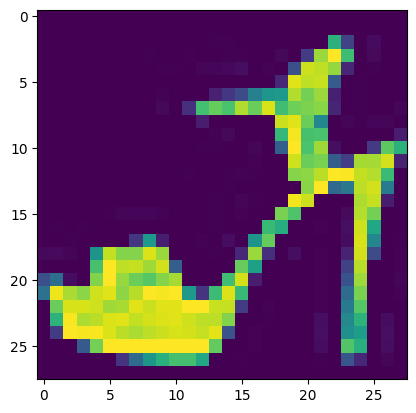

In [11]:
# Visualize
print(f"Clothing Shape",{pixels.shape})
plt.imshow(pixels.squeeze())

Looks like the first item is actually a type of shoe.
matplotlib will take in a 2d shape to make a plot, but as our tensor is 3d([1, 28, 28]), we use .squeeze
This basically removes an dimension that has a size of exactly 1, and that would remove our greyscale color, thus why we're having this neon one.

Clothing Shape {torch.Size([1, 28, 28])}


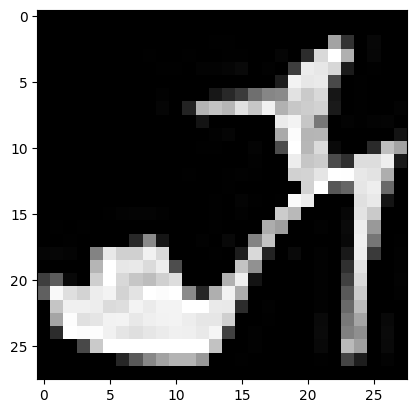

In [12]:
# Visualize again
print(f"Clothing Shape",{pixels.shape})
plt.imshow(pixels.squeeze(), cmap='grey')

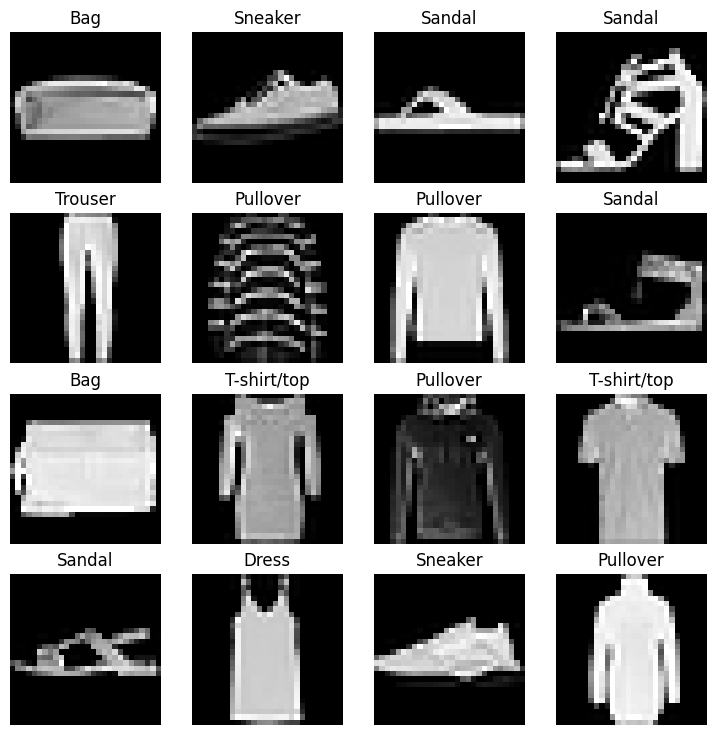

In [13]:
# Plot more images
# torch.manual_seed(42)
fig = plt.figure(figsize=(9,9))
rows, cols = 4,4
for i in range(1, rows * cols + 1):
    random_idx = torch.randint(0, len(train_data), size=[1]).item()
    img, label = train_data[random_idx]
    fig.add_subplot(rows, cols, i)
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(class_names[label])
    plt.axis(False)

In [14]:
train_data[4]

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.1020, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.7412, 0.8078, 0.7333, 0.1255, 0.0000, 0.0000, 0.0000, 0.1020,
           0.8510, 0.8863, 0.7686, 0.0431, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.7529, 0.8902, 0.9176, 0.9529, 0.9020, 0.5765, 0.9373, 0.9490,
           0.9176, 0.8549, 0.8196, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.6784, 0.8824, 0.8431, 0.9137, 0.9961, 0.0000, 0.7608, 0.9412,
           0.8510, 0.8667, 0.7451, 0.0000, 

In [15]:
# Setting up a dataloader to pass the data into the model
from torch.utils.data import DataLoader


# Setup the batch size hyperparameter
BATCH_SIZE = 32

# Transform the dataset into batches
train_dataloader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)

In [16]:
print(f"DataLoaders: {train_dataloader, test_dataloader}")
print(f"Length of train dataloader {len(train_dataloader)} batches of {BATCH_SIZE}")
print(f"Length of test dataloader {len(test_dataloader)} batches of {BATCH_SIZE}")

DataLoaders: (<torch.utils.data.dataloader.DataLoader object at 0x1171b5940>, <torch.utils.data.dataloader.DataLoader object at 0x1177afd90>)
Length of train dataloader 1875 batches of 32
Length of test dataloader 313 batches of 32


In [17]:
print(train_dataloader)

In [ ]:
# Check out what's inside the training dataloader
# Using the next() and iter() to extract the data into new variables
train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

Image size: torch.Size([1, 28, 28])
Label: 9, label size: torch.Size([])


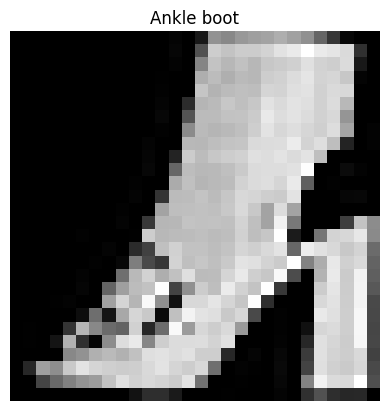

In [53]:
# Show a sample
torch.manual_seed(42)
random_idx = torch.randint(0, len(train_features_batch), size=[1]).item()
img, label = train_features_batch[random_idx], train_labels_batch[random_idx]
plt.imshow(img.squeeze(), cmap="gray")
plt.title(class_names[label])
plt.axis("Off");
print(f"Image size: {img.shape}")
print(f"Label: {label}, label size: {label.shape}")

Now we create the first model

In [20]:
from torch import nn
class FashionMNISTModelV0(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_shape, out_features=hidden_units),
            nn.Linear(in_features=hidden_units, out_features=output_shape)
        )

    def forward(self, x):
        return self.layer_stack(x)

In [21]:
torch.manual_seed(42)

model_0 = FashionMNISTModelV0(input_shape=784, hidden_units=10, output_shape=len(class_names))
model_0.to('cpu')

FashionMNISTModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [22]:
# Setup loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.1)

We've set the optimizer and loss functions, and we can begin training our model, but how about an experiment first.
Our model will be trained on our CPU, but we can also train it our GPU, and observe the time it takes for both devices to run the training.

In [23]:
# To do this we import timeit.default_timer
from timeit import default_timer as Timer

def print_train_time(start: float, end: float, device: torch.device = None):
    """Prints difference between start and end time.

    Args:
        start (float): Start time of computation (preferred in timeit format). 
        end (float): End time of computation.
        device ([type], optional): Device that compute is running on. Defaults to None.

    Returns:
        float: time between start and end in seconds (higher is longer).
    """
    total_time = end - start
    print(f"Train time on {device}: {total_time:.3f} seconds")
    return total_time